# Load Prediction Experiment

## kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation

This notebook presents a complete, reproducible, and academically rigorous classification experiment using the Load Prediction dataset used in the repository notebook.

The repository notebook loads a Kaggle loan prediction dataset from:

```text
ninzaami/loan-predication
```

The experiment evaluates three model groups:

1. **Baseline machine learning classifiers**
2. **COBRA-based aggregation** using `CombinedClassifier`
3. **KFCProcedure classification** using `KFCClassifier`

The notebook is designed as an experimental appendix and as supporting evidence for **Chapter 7: Experiments and Results** of the thesis.


## 1. Objective

### Purpose

The purpose of this experiment is to evaluate classification performance on the Load Prediction dataset using standard baseline classifiers, COBRA-based aggregation, and the KFCProcedure framework.

The experiment compares conventional supervised classifiers against a hybrid framework that combines divergence-based clustering, cluster-wise local learning, and prediction-space aggregation.

### Research Questions

This experiment addresses the following research questions:

1. How do standard machine learning classifiers perform on the Load Prediction classification task?
2. How does `CombinedClassifier` compare with individual baseline classifiers?
3. How does `KFCClassifier` compare with baseline classifiers and standalone COBRA-based aggregation?
4. Are the observed results stable across repeated train-test splits?

### Expected Evaluation

Since the task is classification, the experiment evaluates models using:

- Accuracy
- Precision
- Recall
- F1-score

The experiment uses repeated evaluation with the required random seeds:

```python
SEEDS = [42, 52, 62, 72, 82]
```

For each seed, the dataset is split, preprocessed, trained, predicted, and evaluated independently.


## 2. Dataset Description

### 2.1 Dataset Overview

The dataset used in this experiment is the Load Prediction dataset used in the repository classification notebook.

The observable repository notebook loads the dataset from Kaggle:

```text
ninzaami/loan-predication
```

The observable file name is:

```text
train_u6lujuX_CVtuZ9i (1).csv
```

The dataset contains applicant, income, loan, credit history, property area, and loan status information.

### 2.2 Feature Description

The observable feature columns include:

- `Loan_ID`
- `Gender`
- `Married`
- `Dependents`
- `Education`
- `Self_Employed`
- `ApplicantIncome`
- `CoapplicantIncome`
- `LoanAmount`
- `Loan_Amount_Term`
- `Credit_History`
- `Property_Area`

`Loan_ID` is an identifier and is dropped before modeling, following the repository notebook.

Detailed semantic definitions of each variable beyond the observable column names are **not observable from the provided materials**.

### 2.3 Target Variable

The target column is:

```text
Loan_Status
```

The target is mapped as follows:

- `Y` → `1`
- `N` → `0`


## 3. Exploratory Data Analysis (EDA)

The EDA section follows the dataset and repository-supported workflow:

1. Dataset shape
2. Data types
3. Missing value analysis
4. Duplicate analysis
5. Target distribution
6. Feature statistics
7. Correlation analysis
8. Additional visualizations

The repository notebook checks missing values using `df.isnull().sum()`, visualizes the target distribution, and uses preprocessing pipelines to handle missing values. Duplicate analysis, descriptive statistics, and additional visualizations are included here for thesis reporting and data transparency.

A formal outlier-removal procedure is **not observable from the provided materials**. Therefore, outliers are inspected visually but not removed.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


### Repository Import Configuration

This notebook uses repository modules directly:

- `CombinedClassifier`
- `KFCClassifier`

The import cell first attempts to import the package from the active Python environment. If that fails, it searches upward for a local repository structure containing `src/kfc_procedure`.


In [2]:
def find_repo_root(start_path=None):
    '''
    Locate the repository root containing src/kfc_procedure.
    '''
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "src" / "kfc_procedure").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing src/kfc_procedure. "
        "Run this notebook inside the kfc-procedure repository or install the package."
    )


try:
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCClassifier
    print("Imported kfc_procedure from installed environment.")
except ImportError:
    repo_root = find_repo_root()
    sys.path.insert(0, str(repo_root / "src"))

    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    from kfc_procedure.kfc import KFCClassifier

    print(f"Imported kfc_procedure from source path: {repo_root / 'src'}")


Imported kfc_procedure from installed environment.


### 3.1 Dataset Loading

The dataset is loaded using the Kaggle dataset source used in the repository notebook.

A local CSV path may be supplied through `DATASET_CSV_PATH` for offline reproducibility. If no local path is supplied, the notebook downloads the public Kaggle dataset using `kagglehub`.


In [3]:
DATASET_CSV_PATH = None  # Example: "data/train_u6lujuX_CVtuZ9i (1).csv"
KAGGLE_DATASET = "ninzaami/loan-predication"
DATASET_FILENAME = "train_u6lujuX_CVtuZ9i (1).csv"

if DATASET_CSV_PATH is not None:
    csv_path = Path(DATASET_CSV_PATH)
else:
    try:
        from kagglehub import dataset_download
    except ImportError:
        %pip install kagglehub
        from kagglehub import dataset_download

    dataset_path = Path(dataset_download(KAGGLE_DATASET))
    csv_path = dataset_path / DATASET_FILENAME

if not csv_path.exists():
    raise FileNotFoundError(f"Dataset file was not found: {csv_path}")

df_raw = pd.read_csv(csv_path)
df_raw.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 3.1 Dataset Shape

The dataset shape reports the number of observations and variables before any cleaning procedure.


In [4]:
print("Raw dataset shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])


Raw dataset shape: (614, 13)
Number of rows: 614
Number of columns: 13


### 3.2 Data Types

The following table reports the data type of each column in the raw dataset.


In [5]:
data_types_table = pd.DataFrame({
    "Feature": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
})

display(data_types_table)


,Feature,Data Type
0,Loan_ID,str
1,Gender,str
2,Married,str
3,Dependents,str
4,Education,str
5,Self_Employed,str
6,ApplicantIncome,int64
7,CoapplicantIncome,float64
8,LoanAmount,float64
9,Loan_Amount_Term,float64


### 3.3 Missing Value Analysis

Missing values are checked using:

```python
df.isnull().sum()
```

The repository notebook handles missing values during preprocessing using:

- Median imputation for numerical variables
- Most frequent imputation for categorical variables


In [6]:
missing_values_table = (
    df_raw
    .isnull()
    .sum()
    .reset_index()
)

missing_values_table.columns = ["Feature", "Missing Values"]
missing_values_table["Missing Percentage"] = (
    missing_values_table["Missing Values"] / len(df_raw) * 100
)

display(missing_values_table)
print("Total missing values:", int(df_raw.isnull().sum().sum()))


,Feature,Missing Values,Missing Percentage
0,Loan_ID,0,0.000000
1,Gender,13,2.117264
2,Married,3,0.488599
3,Dependents,15,2.442997
4,Education,0,0.000000
5,Self_Employed,32,5.211726
6,ApplicantIncome,0,0.000000
7,CoapplicantIncome,0,0.000000
8,LoanAmount,22,3.583062
9,Loan_Amount_Term,14,2.280130


Total missing values: 149


### 3.4 Duplicate Analysis

Duplicate rows are inspected using:

```python
df.duplicated().sum()
```

The exact duplicate count depends on the dataset version loaded from Kaggle. This notebook computes the value directly instead of hard-coding it.


In [7]:
duplicate_count = int(df_raw.duplicated().sum())

duplicate_analysis_table = pd.DataFrame({
    "Statistic": ["Duplicate rows", "Duplicate percentage"],
    "Value": [duplicate_count, duplicate_count / len(df_raw) * 100],
})

display(duplicate_analysis_table)


,Statistic,Value
0,Duplicate rows,0.0
1,Duplicate percentage,0.0


### 3.5 Target Distribution

The target distribution is inspected before model training to understand the class balance of `Loan_Status`.


In [8]:
target_column = "Loan_Status"

if target_column not in df_raw.columns:
    raise ValueError(f"Target column '{target_column}' was not found in the dataset.")

target_distribution_table = (
    df_raw[target_column]
    .value_counts(dropna=False)
    .reset_index()
)
target_distribution_table.columns = ["Target Class", "Count"]
target_distribution_table["Percentage"] = (
    target_distribution_table["Count"] / len(df_raw) * 100
)

display(target_distribution_table)


,Target Class,Count,Percentage
0,Y,422,68.729642
1,N,192,31.270358


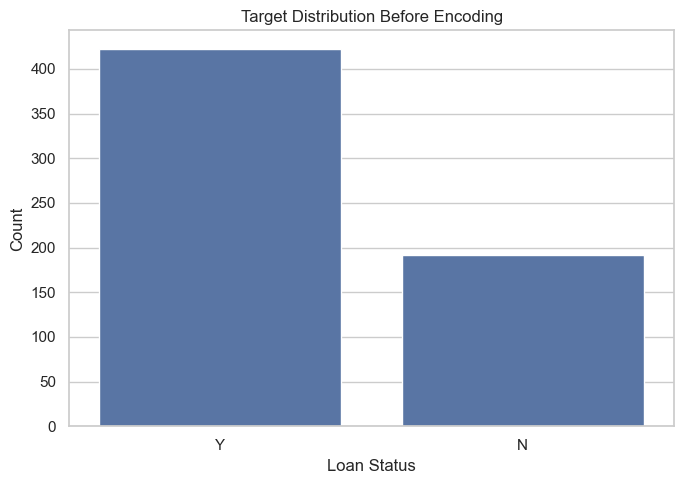

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_raw, x=target_column)
plt.title("Target Distribution Before Encoding")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### 3.6 Feature Statistics

The following descriptive statistics summarize the numerical columns in the raw dataset.


In [10]:
feature_statistics_table = df_raw.describe(include="all").T
feature_statistics_table


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


### 3.7 Correlation Analysis

Correlation analysis is performed on the numerical columns after target encoding. Categorical variables are not included in this correlation matrix unless they are numerically encoded.


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715,-0.004710
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056,-0.059187
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433,-0.037318
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470,-0.021268
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000,0.561678
Loan_Status,-0.004710,-0.059187,-0.037318,-0.021268,0.561678,1.000000


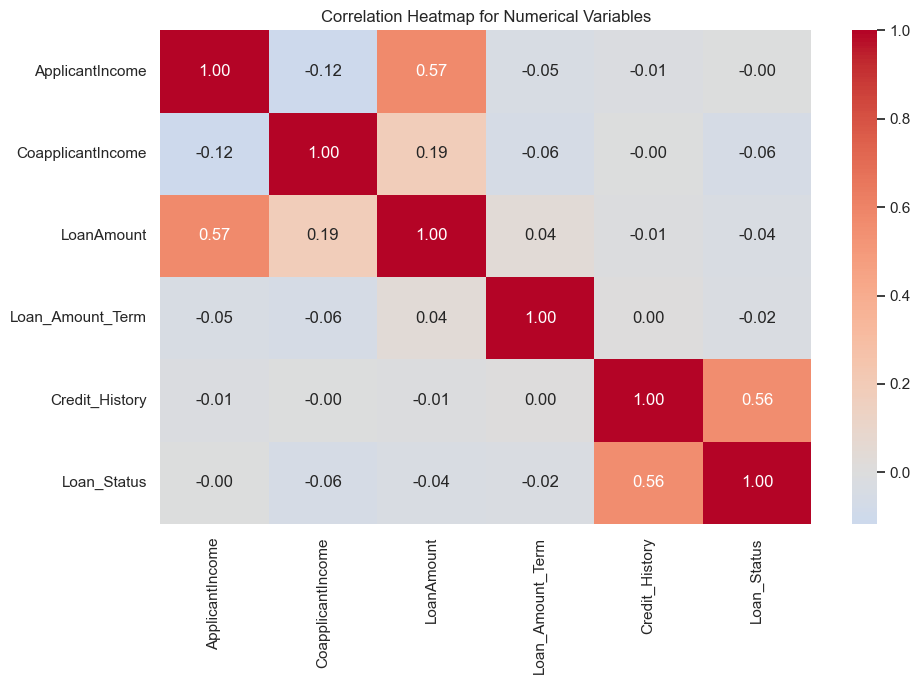

In [11]:
df_corr = df_raw.copy()
df_corr[target_column] = df_corr[target_column].astype(str).str.strip().map({"Y": 1, "N": 0})

numeric_for_corr = df_corr.select_dtypes(include=["number"])
correlation_matrix = numeric_for_corr.corr()

display(correlation_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap for Numerical Variables")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### 3.8 Additional Visualizations

The following visualizations summarize numerical feature distributions and selected categorical distributions. These plots support exploratory interpretation but are not used as feature selection rules.


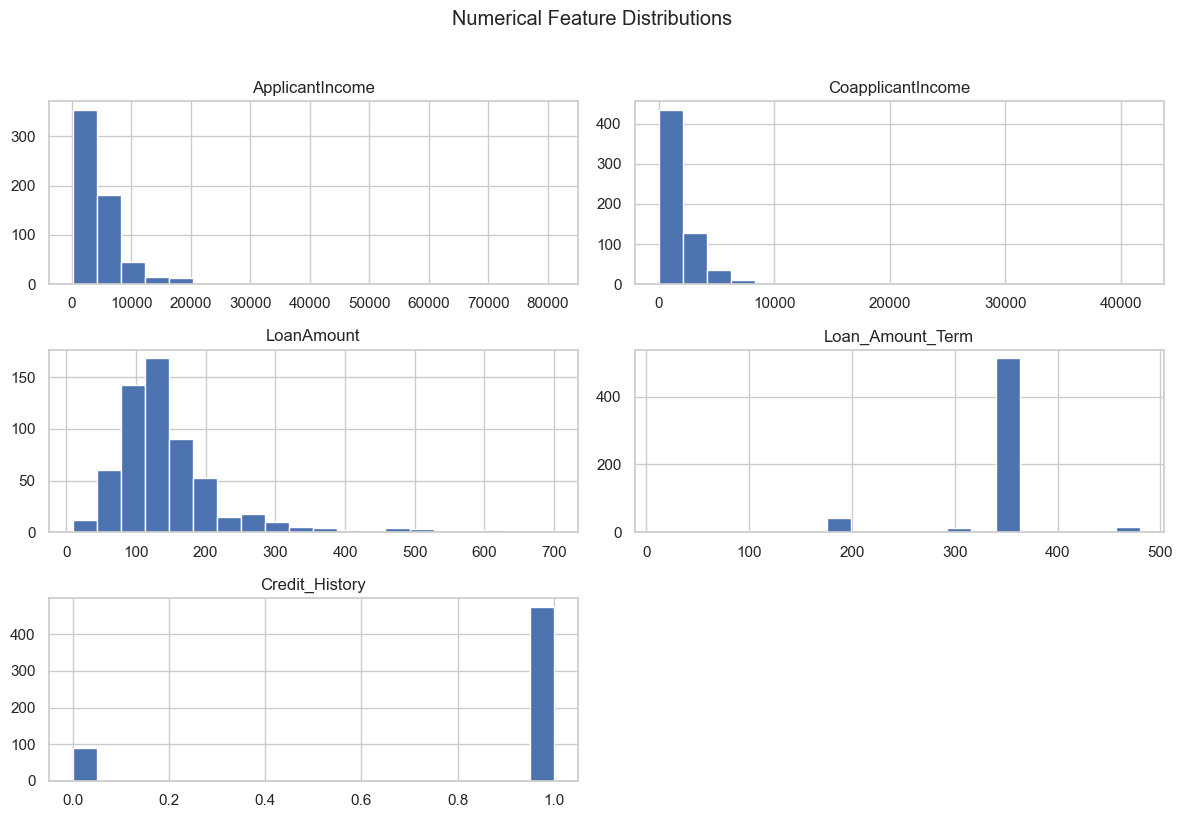

In [12]:
numeric_columns_raw = df_raw.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

if numeric_columns_raw:
    df_raw[numeric_columns_raw].hist(figsize=(12, 8), bins=20)
    plt.suptitle("Numerical Feature Distributions", y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "load_prediction_numeric_distributions.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No numerical columns available for histogram visualization.")


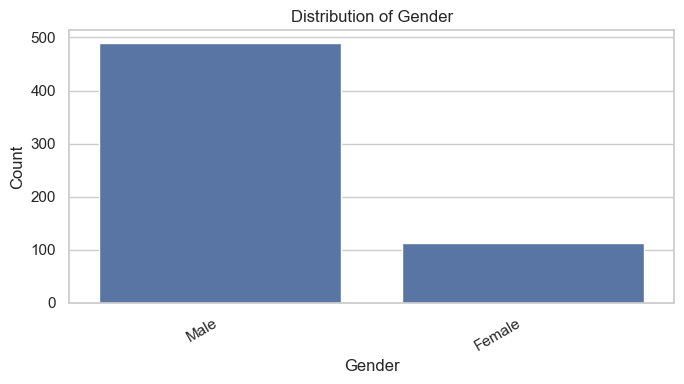

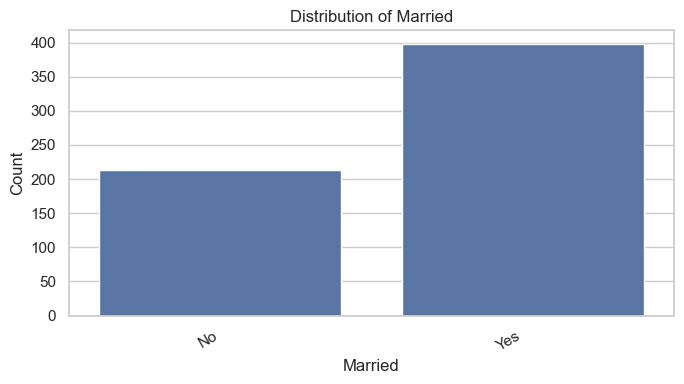

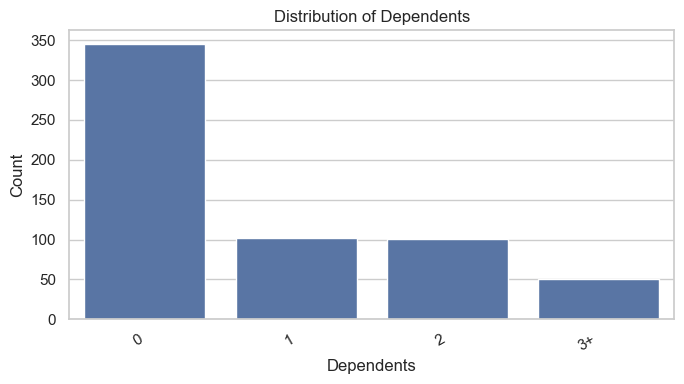

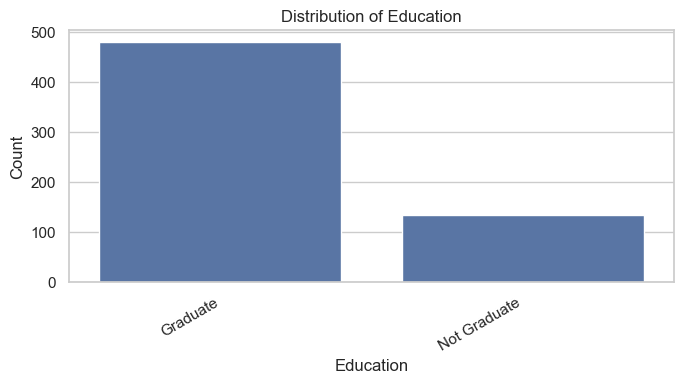

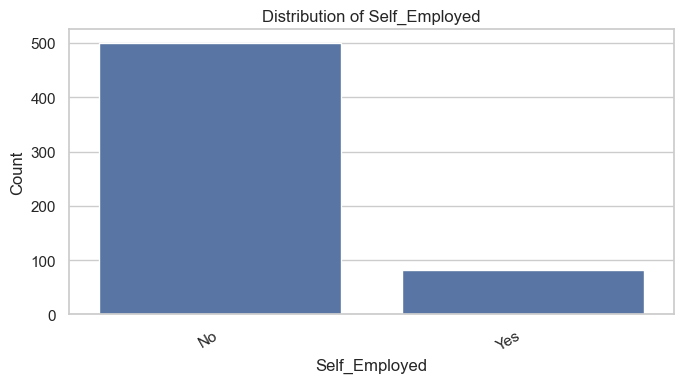

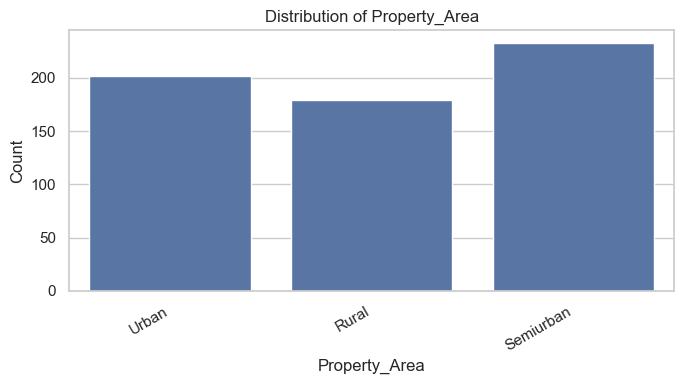

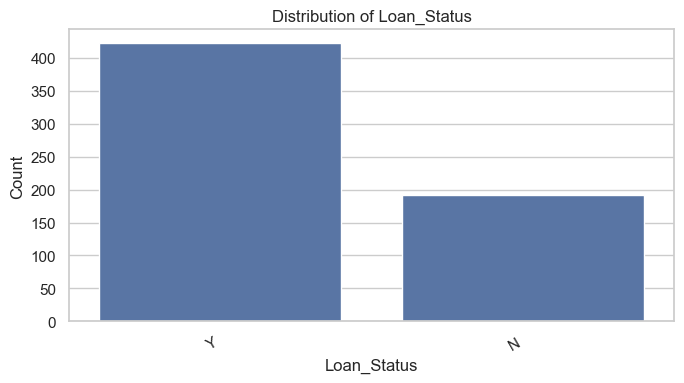

In [13]:
categorical_columns_raw = df_raw.select_dtypes(include="object").columns.tolist()
categorical_columns_raw = [col for col in categorical_columns_raw if col != "Loan_ID"]

for column in categorical_columns_raw:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df_raw, x=column)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"load_prediction_{column}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


## 4. Data Cleaning

### 4.1 Missing Value Handling

Missing values are not removed at the raw-data stage. The repository notebook handles them inside the preprocessing pipeline:

- Numerical variables: `SimpleImputer(strategy="median")`
- Categorical variables: `SimpleImputer(strategy="most_frequent")`

This prevents information leakage when preprocessing is fitted only on the training split.

### 4.2 Duplicate Removal

Exact duplicate rows are removed if they are present. The duplicate count is computed directly from the loaded dataset.

### 4.3 Outlier Inspection

A formal outlier-removal procedure is **not observable from the provided materials**. Therefore, no outlier filtering is applied. Boxplots are used only for inspection.

### 4.4 Data Consistency Checks

The notebook checks that:

- The target column exists.
- The target can be mapped to binary labels.
- The identifier column `Loan_ID` is removed before modeling.
- Feature and target matrices have matching row counts.


In [14]:
df = df_raw.copy()

if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' is required.")

rows_before_duplicates = len(df)
df = df.drop_duplicates().copy()
rows_after_duplicates = len(df)

print("Rows before duplicate removal:", rows_before_duplicates)
print("Rows after duplicate removal:", rows_after_duplicates)
print("Rows removed:", rows_before_duplicates - rows_after_duplicates)
print("Remaining duplicate rows:", int(df.duplicated().sum()))

# Encode target as in the repository notebook.
df[target_column] = df[target_column].astype(str).str.strip().map({"Y": 1, "N": 0})

if df[target_column].isnull().any():
    raise ValueError("Target mapping produced missing values. Check target labels before modeling.")

print("Encoded target classes:", sorted(df[target_column].unique()))


Rows before duplicate removal: 614
Rows after duplicate removal: 614
Rows removed: 0
Remaining duplicate rows: 0
Encoded target classes: [np.int64(0), np.int64(1)]


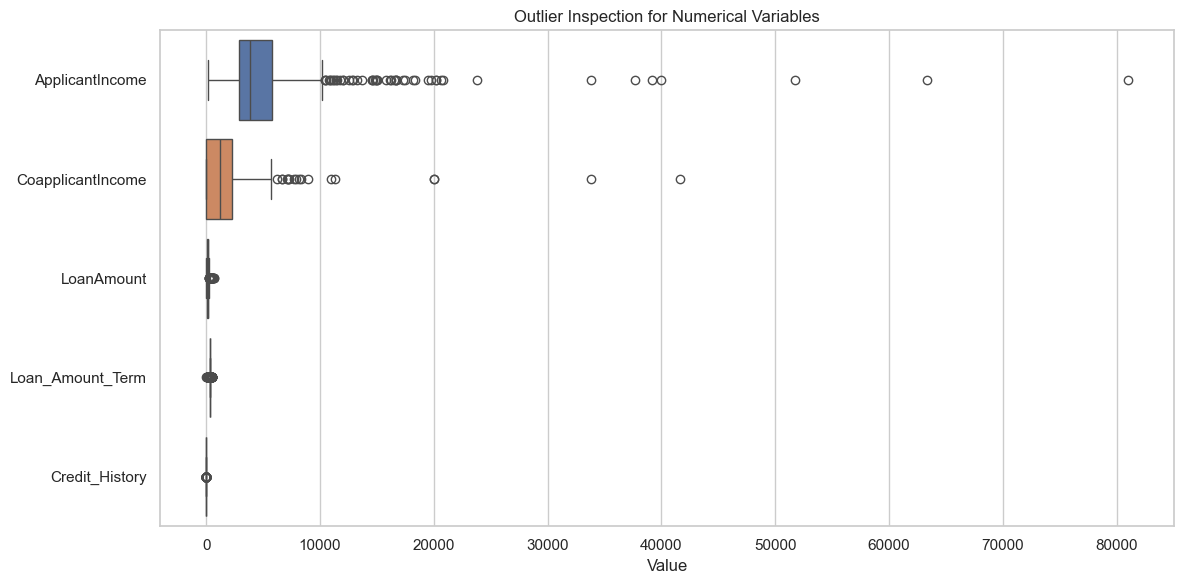

Outlier removal: Not observable from the provided materials.


In [15]:
if numeric_columns_raw:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[numeric_columns_raw], orient="h")
    plt.title("Outlier Inspection for Numerical Variables")
    plt.xlabel("Value")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "load_prediction_outlier_inspection_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No numerical columns available for outlier inspection.")

print("Outlier removal: Not observable from the provided materials.")


## 5. Data Preprocessing

### 5.1 Feature Encoding

Categorical variables are encoded using:

```python
OneHotEncoder(handle_unknown="ignore")
```

### 5.2 Feature Scaling

Numerical variables are scaled using:

```python
StandardScaler()
```

The KFCClassifier additionally uses:

```python
MinMaxScaler(feature_range=(0.05, 0.95))
```

after the repository-supported preprocessing step to keep values in a positive numeric range for divergence-based clustering.

### 5.3 Feature Selection

Feature selection is **not observable from the provided materials**. Therefore, all modeling features except `Loan_ID` and `Loan_Status` are used.

### 5.4 Final Feature Matrix

The final feature matrix is built by dropping:

- `Loan_ID`
- `Loan_Status`

The target vector is `Loan_Status` after binary encoding.


In [16]:
ID_COLUMN = "Loan_ID"

feature_drop_columns = [target_column]
if ID_COLUMN in df.columns:
    feature_drop_columns.append(ID_COLUMN)

X = df.drop(columns=feature_drop_columns)
y = df[target_column]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)


Feature matrix shape: (614, 11)
Target vector shape: (614,)
Categorical columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [17]:
def make_one_hot_encoder():
    '''Create a dense OneHotEncoder compatible with multiple scikit-learn versions.'''
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(num_cols, cat_cols):
    '''Create the repository-supported preprocessing pipeline.'''
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")


def to_dense_array(matrix):
    '''Convert sparse matrices to dense arrays for repository model compatibility.'''
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return np.asarray(matrix)


## 6. Experimental Setup

### 6.1 Environment Configuration

The software environment is recorded for reproducibility.

### 6.2 Random Seed Configuration

The repeated evaluation uses:

```python
SEEDS = [42, 52, 62, 72, 82]
```

### 6.3 Train-Test Split Strategy

For each seed, the dataset is split using:

- `test_size=0.2`
- `stratify=y`
- `random_state=seed`

### 6.4 Hyperparameter Configuration

The model configuration follows the observable repository notebook:

- `LogisticRegression(max_iter=1000)`
- `RandomForestClassifier(n_estimators=300, random_state=seed)`
- `SVC(probability=True)`
- `KNeighborsClassifier()`
- `GaussianNB()`
- `CombinedClassifier(estimators=models.keys(), random_state=seed)`
- `KFCClassifier(divergences=["euclidean", "gkl", "is", "logistic"], local_model="logistic_regression", combiner="combined_classifier", n_clusters=2, random_state=seed)`

### 6.5 Evaluation Protocol

For each seed:

1. Split the data.
2. Fit preprocessing on the training data only.
3. Transform both training and testing data.
4. Train every model using the same seed-specific training split.
5. Predict on the same seed-specific testing split.
6. Store the metrics in `all_results`.


In [18]:
environment_info = {
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Scikit-learn": sklearn.__version__,
}

environment_table = pd.DataFrame(
    environment_info.items(),
    columns=["Component", "Version"],
)

display(environment_table)


,Component,Version
0,Python,3.11.15
1,Platform,macOS-26.5.1-arm64-arm-64bit
2,NumPy,2.4.6
3,Pandas,3.0.3
4,Scikit-learn,1.9.0


In [19]:
SEEDS = [42, 52, 62, 72, 82]
TEST_SIZE = 0.2
SCALER_RANGE = (0.05, 0.95)
PRIMARY_METRIC = "Accuracy"

REPOSITORY_ESTIMATOR_KEYS = [
    "logistic_regression",
    "random_forest_classifier",
    "svc",
    "k_neighbors_classifier",
    "gaussian_nb",
]

print("Seeds:", SEEDS)
print("Test size:", TEST_SIZE)
print("KFC MinMaxScaler range:", SCALER_RANGE)
print("Primary metric:", PRIMARY_METRIC)


Seeds: [42, 52, 62, 72, 82]
Test size: 0.2
KFC MinMaxScaler range: (0.05, 0.95)
Primary metric: Accuracy


## 7. Evaluation Metrics

The experiment uses classification metrics only.

Let:

- TP = true positives
- TN = true negatives
- FP = false positives
- FN = false negatives

### Accuracy

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

Scikit-learn implementation:

```python
accuracy_score(y_true, y_pred)
```

### Precision

\[
Precision = \frac{TP}{TP + FP}
\]

Scikit-learn implementation:

```python
precision_score(y_true, y_pred, average="weighted", zero_division=0)
```

### Recall

\[
Recall = \frac{TP}{TP + FN}
\]

Scikit-learn implementation:

```python
recall_score(y_true, y_pred, average="weighted", zero_division=0)
```

### F1-score

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

Scikit-learn implementation:

```python
f1_score(y_true, y_pred, average="weighted", zero_division=0)
```


In [20]:
def evaluate_classification(y_true, y_pred, average="weighted"):
    '''Evaluate classification predictions using repository-supported metrics.'''
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0,
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average=average,
            zero_division=0,
        ),
    }


## 8. Baseline Models

The baseline classifiers follow the observable repository notebook:

- Logistic Regression
- Random Forest Classifier
- SVC
- KNeighborsClassifier
- GaussianNB

For each baseline model, the experiment performs:

1. Configuration
2. Training
3. Prediction
4. Evaluation

A standalone Decision Tree classifier is not added because it is **not observable from the provided materials** for this dataset experiment.


In [21]:
def make_baseline_models(seed):
    '''Create baseline models for one seed-specific run.'''
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest Classifier": RandomForestClassifier(
            n_estimators=300,
            random_state=seed,
        ),
        "SVC": SVC(probability=True, random_state=seed),
        "KNeighborsClassifier": KNeighborsClassifier(),
        "GaussianNB": GaussianNB(),
    }


## 9. COBRA Experiments

### Configuration

The COBRA classification experiment uses `CombinedClassifier`, which is the repository-supported COBRA classifier used in the Load Prediction notebook.

### Training

For every seed, `CombinedClassifier` is trained on the same preprocessed training split as the baseline models.

### Prediction

Predictions are generated on the same preprocessed test split.

### Evaluation

The predictions are evaluated using Accuracy, Precision, Recall, and F1-score.

### Excluded COBRA Models

- `GradientCOBRA` is not used because the provided materials use `CombinedClassifier` for this classification experiment.
- `MixCOBRARegressor` is regression-only and is not appropriate for this classification task.
- `SuperLearner` is not used because its use in this specific Load Prediction classification notebook is **not observable from the provided materials**.


In [22]:
def make_combined_classifier(seed):
    '''Create the repository-supported CombinedClassifier.'''
    return CombinedClassifier(
        estimators=REPOSITORY_ESTIMATOR_KEYS,
        random_state=seed,
    )


## 10. KFCProcedure Experiments

### Configuration

The KFCProcedure classification experiment uses `KFCClassifier`.

### K-Step

The K-Step performs divergence-based clustering using the repository-supported divergences:

- Euclidean
- Generalized KL (`gkl`)
- Itakura-Saito (`is`)
- Logistic

### F-Step

The F-Step trains cluster-wise local models using:

- Logistic Regression

### C-Step

The C-Step aggregates intermediate predictions using:

- `combined_classifier`

### Training

The KFCClassifier is trained on the same seed-specific training split after preprocessing and positive-range scaling.

### Prediction

The trained KFCClassifier predicts labels for the same seed-specific test split.

### Evaluation

The predictions are evaluated using Accuracy, Precision, Recall, and F1-score.


In [23]:
def make_kfc_classifier(seed):
    '''Create the repository-supported KFCClassifier configuration.'''
    return KFCClassifier(
        divergences=["euclidean", "gkl", "is", "logistic"],
        local_model="logistic_regression",
        combiner="combined_classifier",
        n_clusters=2,
        random_state=seed,
    )


## 11. Repeated Evaluation Procedure

The following function runs one complete seed-specific experiment.

For every seed, it:

1. Splits the data.
2. Fits the preprocessing pipeline on the training split only.
3. Transforms training and testing features.
4. Trains baseline classifiers.
5. Trains `CombinedClassifier`.
6. Trains `KFCClassifier`.
7. Stores model, seed, metrics, fit time, and prediction time.


In [24]:
def run_single_seed_experiment(seed, X, y):
    '''Run one seed-specific train-test experiment.'''
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=seed,
    )

    preprocessor = make_preprocessor(num_cols=num_cols, cat_cols=cat_cols)

    X_train_processed = to_dense_array(preprocessor.fit_transform(X_train))
    X_test_processed = to_dense_array(preprocessor.transform(X_test))

    seed_results = []

    baseline_models = make_baseline_models(seed)

    for model_name, model in baseline_models.items():
        start_fit = time.perf_counter()
        model.fit(X_train_processed, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_processed)
        predict_time = time.perf_counter() - start_predict

        metrics = evaluate_classification(y_test, y_pred)

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **metrics,
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    combined_classifier = make_combined_classifier(seed)

    start_fit = time.perf_counter()
    combined_classifier.fit(X_train_processed, y_train)
    fit_time = time.perf_counter() - start_fit

    start_predict = time.perf_counter()
    y_pred_combined = combined_classifier.predict(X_test_processed)
    predict_time = time.perf_counter() - start_predict

    combined_metrics = evaluate_classification(y_test, y_pred_combined)

    seed_results.append({
        "Model": "CombinedClassifier",
        "Seed": seed,
        **combined_metrics,
        "Fit Time": fit_time,
        "Prediction Time": predict_time,
    })

    kfc_scaler = MinMaxScaler(feature_range=SCALER_RANGE)
    X_train_kfc = kfc_scaler.fit_transform(X_train_processed)
    X_test_kfc = kfc_scaler.transform(X_test_processed)

    kfc_classifier = make_kfc_classifier(seed)

    start_fit = time.perf_counter()
    kfc_classifier.fit(X_train_kfc, y_train)
    fit_time = time.perf_counter() - start_fit

    start_predict = time.perf_counter()
    y_pred_kfc = kfc_classifier.predict(X_test_kfc)
    predict_time = time.perf_counter() - start_predict

    kfc_metrics = evaluate_classification(y_test, y_pred_kfc)

    seed_results.append({
        "Model": "KFCClassifier",
        "Seed": seed,
        **kfc_metrics,
        "Fit Time": fit_time,
        "Prediction Time": predict_time,
    })

    return seed_results


### Execute Repeated Evaluation

The required result storage object is:

```python
all_results = []
```

Each row stores:

- Model
- Seed
- Accuracy
- Precision
- Recall
- F1-score
- Fit time
- Prediction time


In [25]:
def run_repeated_experiment(X, y, seeds):
    '''Run the complete repeated evaluation procedure.'''
    all_results = []

    for seed in seeds:
        print(f"Running experiment for seed = {seed}")
        seed_results = run_single_seed_experiment(seed, X, y)
        all_results.extend(seed_results)

    return all_results


if __name__ == "__main__":
    all_results = run_repeated_experiment(X, y, SEEDS)
    per_seed_results_table = pd.DataFrame(all_results)

per_seed_results_table


Running experiment for seed = 42


search: 100%|██████████| 300/300 [00:00<00:00, 510.05it/s]


Running experiment for seed = 52


search: 100%|██████████| 300/300 [00:00<00:00, 497.75it/s]


Running experiment for seed = 62


...

Running experiment for seed = 72


search: 100%|██████████| 300/300 [00:00<00:00, 519.10it/s]


Running experiment for seed = 82


search: 100%|██████████| 300/300 [00:00<00:00, 500.33it/s]


,Model,Seed,Accuracy,Precision,Recall,F1 Score,Fit Time,Prediction Time
0,Logistic Regression,42,0.861789,0.875999,0.861789,0.850399,0.002286,0.000115
1,Random Forest Classifier,42,0.821138,0.816452,0.821138,0.814636,0.143328,0.008978
2,SVC,42,0.853659,0.869641,0.853659,0.840441,0.011809,0.000936
3,KNeighborsClassifier,42,0.869919,0.882422,0.869919,0.860181,0.000234,0.011712
4,GaussianNB,42,0.845528,0.850101,0.845528,0.835078,0.000812,0.000114
5,CombinedClassifier,42,0.861789,0.875999,0.861789,0.850399,0.890544,0.008429
6,KFCClassifier,42,0.837398,0.857076,0.837398,0.819951,0.850384,0.003118
7,Logistic Regression,52,0.829268,0.850844,0.829268,0.809395,0.003188,0.000104
8,Random Forest Classifier,52,0.804878,0.806986,0.804878,0.787254,0.140962,0.009074
9,SVC,52,0.821138,0.844625,0.821138,0.798612,0.011607,0.000916


## 11. Results Summary

### 11.1 Per-Seed Results

The per-seed table reports each model's result for each random seed.


In [26]:
per_seed_results_table = per_seed_results_table[
    [
        "Model",
        "Seed",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Fit Time",
        "Prediction Time",
    ]
].sort_values(["Seed", "Model"]).reset_index(drop=True)

per_seed_results_table.to_csv(TABLE_DIR / "load_prediction_per_seed_results.csv", index=False)
per_seed_results_table


,Model,Seed,Accuracy,Precision,Recall,F1 Score,Fit Time,Prediction Time
0,CombinedClassifier,42,0.861789,0.875999,0.861789,0.850399,0.890544,0.008429
1,GaussianNB,42,0.845528,0.850101,0.845528,0.835078,0.000812,0.000114
2,KFCClassifier,42,0.837398,0.857076,0.837398,0.819951,0.850384,0.003118
3,KNeighborsClassifier,42,0.869919,0.882422,0.869919,0.860181,0.000234,0.011712
4,Logistic Regression,42,0.861789,0.875999,0.861789,0.850399,0.002286,0.000115
5,Random Forest Classifier,42,0.821138,0.816452,0.821138,0.814636,0.143328,0.008978
6,SVC,42,0.853659,0.869641,0.853659,0.840441,0.011809,0.000936
7,CombinedClassifier,52,0.813008,0.838400,0.813008,0.787589,0.667171,0.006082
8,GaussianNB,52,0.788618,0.781461,0.788618,0.775769,0.000423,0.000115
9,KFCClassifier,52,0.804878,0.832146,0.804878,0.776310,0.636299,0.003084


### 11.2 Aggregated Results

The aggregated table reports the mean and standard deviation of each metric across the repeated evaluation seeds.


In [27]:
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]

aggregated_results_table = (
    per_seed_results_table
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

aggregated_results_table = aggregated_results_table.sort_values(
    by=("Accuracy", "mean"),
    ascending=False,
)

aggregated_results_table


Accuracy           Precision              Recall            F1 Score          
                              mean       std      mean       std      mean       std      mean       std
Model                                                                                                   
Logistic Regression       0.826016  0.024118  0.850834  0.019768  0.826016  0.024118  0.803640  0.031602
CombinedClassifier        0.821138  0.025710  0.844841  0.023878  0.821138  0.025710  0.797822  0.032928
SVC                       0.817886  0.023423  0.837952  0.024102  0.817886  0.023423  0.795102  0.029520
KNeighborsClassifier      0.817886  0.033816  0.824490  0.042082  0.817886  0.033816  0.801711  0.036988
Random Forest Classifier  0.814634  0.015639  0.818022  0.023485  0.814634  0.015639  0.799888  0.017179
KFCClassifier             0.811382  0.021044  0.830160  0.025669  0.811382  0.021044  0.787353  0.025854
GaussianNB                0.804878  0.027570  0.804520  0.033486  0.804878  0.027570  0.789541  0.029710

In [28]:
flat_aggregated_results = aggregated_results_table.copy()
flat_aggregated_results.columns = [
    f"{metric} {stat.title()}"
    for metric, stat in flat_aggregated_results.columns
]
flat_aggregated_results = flat_aggregated_results.reset_index()

flat_aggregated_results.to_csv(TABLE_DIR / "load_prediction_aggregated_results.csv", index=False)
flat_aggregated_results


,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Score Mean,F1 Score Std
0,Logistic Regression,0.826016,0.024118,0.850834,0.019768,0.826016,0.024118,0.803640,0.031602
1,CombinedClassifier,0.821138,0.025710,0.844841,0.023878,0.821138,0.025710,0.797822,0.032928
2,SVC,0.817886,0.023423,0.837952,0.024102,0.817886,0.023423,0.795102,0.029520
3,KNeighborsClassifier,0.817886,0.033816,0.824490,0.042082,0.817886,0.033816,0.801711,0.036988
4,Random Forest Classifier,0.814634,0.015639,0.818022,0.023485,0.814634,0.015639,0.799888,0.017179
5,KFCClassifier,0.811382,0.021044,0.830160,0.025669,0.811382,0.021044,0.787353,0.025854
6,GaussianNB,0.804878,0.027570,0.804520,0.033486,0.804878,0.027570,0.789541,0.029710


### 11.3 Mean ± Standard Deviation Reporting

The following table formats the aggregated metrics as:

```text
mean ± standard deviation
```

This format is suitable for thesis reporting.


In [29]:
def format_mean_std(mean_value, std_value, decimals=3):
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


formatted_aggregated_results = pd.DataFrame({
    "Model": flat_aggregated_results["Model"],
})

for metric in metric_columns:
    formatted_aggregated_results[metric] = [
        format_mean_std(mean_value, std_value)
        for mean_value, std_value in zip(
            flat_aggregated_results[f"{metric} Mean"],
            flat_aggregated_results[f"{metric} Std"],
        )
    ]

formatted_aggregated_results.to_csv(TABLE_DIR / "load_prediction_formatted_aggregated_results.csv", index=False)
formatted_aggregated_results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.826 ± 0.024,0.851 ± 0.020,0.826 ± 0.024,0.804 ± 0.032
1,CombinedClassifier,0.821 ± 0.026,0.845 ± 0.024,0.821 ± 0.026,0.798 ± 0.033
2,SVC,0.818 ± 0.023,0.838 ± 0.024,0.818 ± 0.023,0.795 ± 0.030
3,KNeighborsClassifier,0.818 ± 0.034,0.824 ± 0.042,0.818 ± 0.034,0.802 ± 0.037
4,Random Forest Classifier,0.815 ± 0.016,0.818 ± 0.023,0.815 ± 0.016,0.800 ± 0.017
5,KFCClassifier,0.811 ± 0.021,0.830 ± 0.026,0.811 ± 0.021,0.787 ± 0.026
6,GaussianNB,0.805 ± 0.028,0.805 ± 0.033,0.805 ± 0.028,0.790 ± 0.030


### 11.4 Model Ranking

The ranking table orders models by the primary metric:

```python
PRIMARY_METRIC = "Accuracy"
```


In [30]:
ranking_table = flat_aggregated_results[
    ["Model", f"{PRIMARY_METRIC} Mean", f"{PRIMARY_METRIC} Std"]
].copy()

ranking_table = ranking_table.sort_values(
    by=f"{PRIMARY_METRIC} Mean",
    ascending=False,
).reset_index(drop=True)

ranking_table.insert(0, "Rank", ranking_table.index + 1)
ranking_table.to_csv(TABLE_DIR / "load_prediction_model_ranking.csv", index=False)
ranking_table


,Rank,Model,Accuracy Mean,Accuracy Std
0,1,Logistic Regression,0.826016,0.024118
1,2,CombinedClassifier,0.821138,0.025710
2,3,SVC,0.817886,0.023423
3,4,KNeighborsClassifier,0.817886,0.033816
4,5,Random Forest Classifier,0.814634,0.015639
5,6,KFCClassifier,0.811382,0.021044
6,7,GaussianNB,0.804878,0.027570


### 11.5 Best Model Analysis

The following cell identifies the best model based on mean accuracy.


In [31]:
best_model_name = ranking_table.loc[0, "Model"]
best_model_accuracy = ranking_table.loc[0, f"{PRIMARY_METRIC} Mean"]
best_model_accuracy_std = ranking_table.loc[0, f"{PRIMARY_METRIC} Std"]

best_model_summary = formatted_aggregated_results[
    formatted_aggregated_results["Model"] == best_model_name
]

print("Best model by mean accuracy:", best_model_name)
print("Accuracy:", format_mean_std(best_model_accuracy, best_model_accuracy_std, decimals=3))

display(best_model_summary)


Best model by mean accuracy: Logistic Regression
Accuracy: 0.826 ± 0.024


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.826 ± 0.024,0.851 ± 0.020,0.826 ± 0.024,0.804 ± 0.032


## 12. Required Visualizations

The following figures are generated for thesis reporting:

- Target distribution
- Correlation heatmap
- Model comparison bar chart
- Ranking chart
- Metric comparison chart


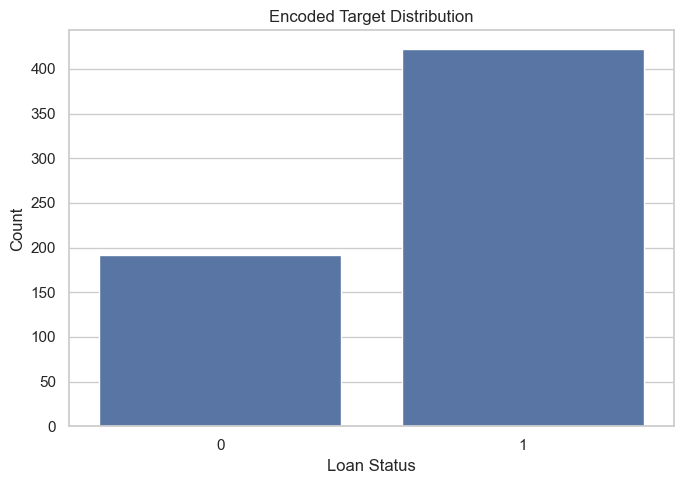

In [32]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title("Encoded Target Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_encoded_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


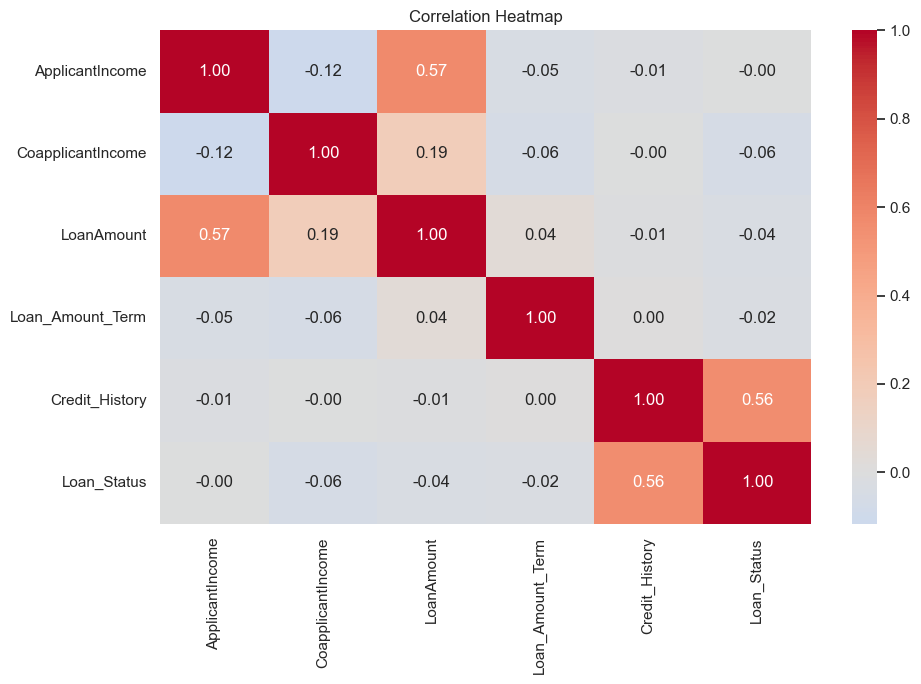

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_required_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


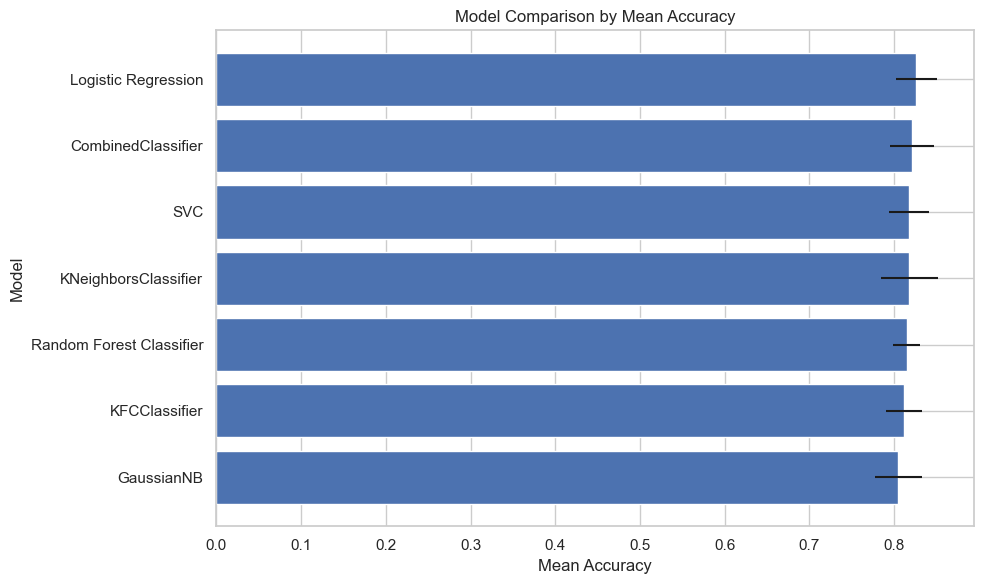

In [34]:
comparison_plot_data = flat_aggregated_results.sort_values(
    by="Accuracy Mean",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    comparison_plot_data["Model"],
    comparison_plot_data["Accuracy Mean"],
    xerr=comparison_plot_data["Accuracy Std"],
)
plt.title("Model Comparison by Mean Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_model_comparison_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


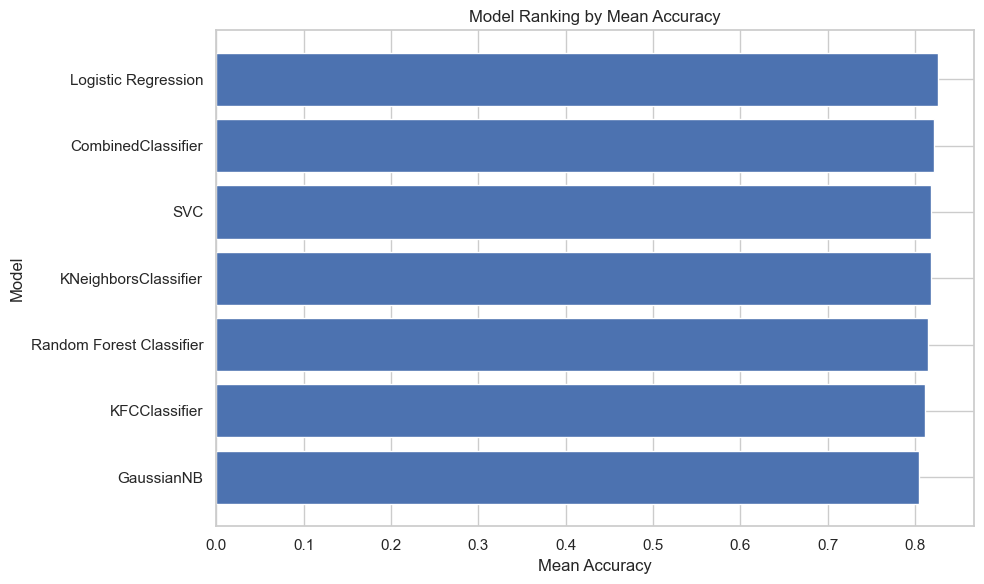

In [35]:
ranking_plot_data = ranking_table.sort_values(
    by=f"{PRIMARY_METRIC} Mean",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    ranking_plot_data["Model"],
    ranking_plot_data[f"{PRIMARY_METRIC} Mean"],
)
plt.title("Model Ranking by Mean Accuracy")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_ranking_chart.png", dpi=300, bbox_inches="tight")
plt.show()


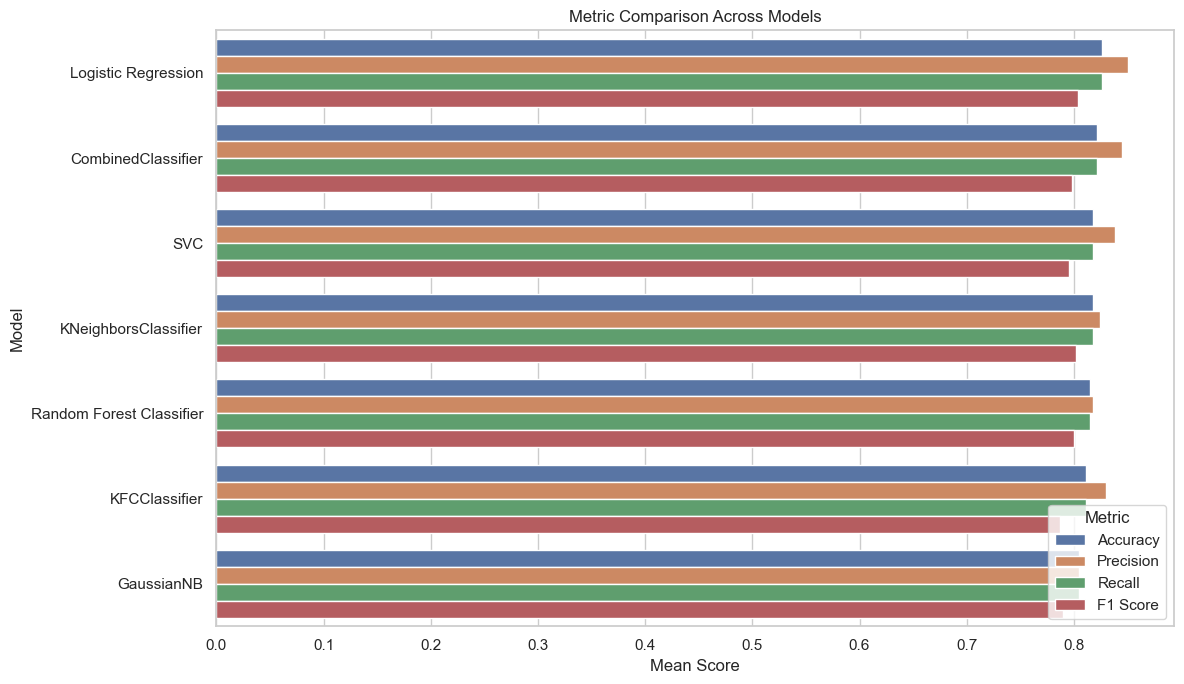

In [36]:
metric_comparison_long = flat_aggregated_results.melt(
    id_vars="Model",
    value_vars=[f"{metric} Mean" for metric in metric_columns],
    var_name="Metric",
    value_name="Mean Score",
)
metric_comparison_long["Metric"] = metric_comparison_long["Metric"].str.replace(" Mean", "", regex=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metric_comparison_long,
    x="Mean Score",
    y="Model",
    hue="Metric",
    orient="h",
)
plt.title("Metric Comparison Across Models")
plt.xlabel("Mean Score")
plt.ylabel("Model")
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "load_prediction_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. LaTeX-Ready Tables

The following cells generate LaTeX tables directly from the computed results.

No values are manually inserted.


In [37]:
latex_per_seed_table = per_seed_results_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Per-seed Load Prediction classification results.",
    label="tab:load_prediction_per_seed_results",
)

print(latex_per_seed_table)


\begin{table}
\caption{Per-seed Load Prediction classification results.}
\label{tab:load_prediction_per_seed_results}
\begin{tabular}{lrrrrrrr}
\toprule
Model & Seed & Accuracy & Precision & Recall & F1 Score & Fit Time & Prediction Time \\
\midrule
CombinedClassifier & 42 & 0.8618 & 0.8760 & 0.8618 & 0.8504 & 0.8905 & 0.0084 \\
GaussianNB & 42 & 0.8455 & 0.8501 & 0.8455 & 0.8351 & 0.0008 & 0.0001 \\
KFCClassifier & 42 & 0.8374 & 0.8571 & 0.8374 & 0.8200 & 0.8504 & 0.0031 \\
KNeighborsClassifier & 42 & 0.8699 & 0.8824 & 0.8699 & 0.8602 & 0.0002 & 0.0117 \\
Logistic Regression & 42 & 0.8618 & 0.8760 & 0.8618 & 0.8504 & 0.0023 & 0.0001 \\
Random Forest Classifier & 42 & 0.8211 & 0.8165 & 0.8211 & 0.8146 & 0.1433 & 0.0090 \\
SVC & 42 & 0.8537 & 0.8696 & 0.8537 & 0.8404 & 0.0118 & 0.0009 \\
CombinedClassifier & 52 & 0.8130 & 0.8384 & 0.8130 & 0.7876 & 0.6672 & 0.0061 \\
GaussianNB & 52 & 0.7886 & 0.7815 & 0.7886 & 0.7758 & 0.0004 & 0.0001 \\
KFCClassifier & 52 & 0.8049 & 0.8321 & 0.8049 & 

In [38]:
latex_aggregated_table = formatted_aggregated_results.to_latex(
    index=False,
    escape=False,
    caption="Aggregated Load Prediction classification results across five random seeds.",
    label="tab:load_prediction_aggregated_results",
)

print(latex_aggregated_table)


\begin{table}
\caption{Aggregated Load Prediction classification results across five random seeds.}
\label{tab:load_prediction_aggregated_results}
\begin{tabular}{lllll}
\toprule
Model & Accuracy & Precision & Recall & F1 Score \\
\midrule
Logistic Regression & 0.826 ± 0.024 & 0.851 ± 0.020 & 0.826 ± 0.024 & 0.804 ± 0.032 \\
CombinedClassifier & 0.821 ± 0.026 & 0.845 ± 0.024 & 0.821 ± 0.026 & 0.798 ± 0.033 \\
SVC & 0.818 ± 0.023 & 0.838 ± 0.024 & 0.818 ± 0.023 & 0.795 ± 0.030 \\
KNeighborsClassifier & 0.818 ± 0.034 & 0.824 ± 0.042 & 0.818 ± 0.034 & 0.802 ± 0.037 \\
Random Forest Classifier & 0.815 ± 0.016 & 0.818 ± 0.023 & 0.815 ± 0.016 & 0.800 ± 0.017 \\
KFCClassifier & 0.811 ± 0.021 & 0.830 ± 0.026 & 0.811 ± 0.021 & 0.787 ± 0.026 \\
GaussianNB & 0.805 ± 0.028 & 0.805 ± 0.033 & 0.805 ± 0.028 & 0.790 ± 0.030 \\
\bottomrule
\end{tabular}
\end{table}



In [39]:
latex_ranking_table = ranking_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model ranking by mean accuracy for the Load Prediction classification experiment.",
    label="tab:load_prediction_model_ranking",
)

print(latex_ranking_table)


\begin{table}
\caption{Model ranking by mean accuracy for the Load Prediction classification experiment.}
\label{tab:load_prediction_model_ranking}
\begin{tabular}{rlrr}
\toprule
Rank & Model & Accuracy Mean & Accuracy Std \\
\midrule
1 & Logistic Regression & 0.8260 & 0.0241 \\
2 & CombinedClassifier & 0.8211 & 0.0257 \\
3 & SVC & 0.8179 & 0.0234 \\
4 & KNeighborsClassifier & 0.8179 & 0.0338 \\
5 & Random Forest Classifier & 0.8146 & 0.0156 \\
6 & KFCClassifier & 0.8114 & 0.0210 \\
7 & GaussianNB & 0.8049 & 0.0276 \\
\bottomrule
\end{tabular}
\end{table}



## 12. Discussion

### Comparison of Baselines

The baseline models provide the reference point for interpreting the value of aggregation-based and clusterwise learning methods. The comparison should be based on the aggregated results table rather than a single split.

The strongest baseline is the baseline model with the highest mean accuracy and F1-score across the five seeds.

### Comparison of COBRA Models

The COBRA classification experiment uses `CombinedClassifier`. Its performance should be compared against both individual baseline models and the KFCProcedure model.

`GradientCOBRA` and `MixCOBRARegressor` are not used because they are not appropriate for this classification experiment. `SuperLearner` is not used because its application to this specific Load Prediction classification notebook is not observable from the provided materials.

### Comparison of KFC Models

The KFCProcedure experiment is represented by `KFCClassifier`. It combines divergence-based clustering, local logistic regression, and `combined_classifier` aggregation.

The KFCClassifier result should be interpreted relative to the best baseline and the standalone `CombinedClassifier` result.

### Strengths

The experiment has the following strengths:

1. It uses repeated evaluation across five random seeds.
2. It applies preprocessing inside each train-test split to avoid data leakage.
3. It evaluates all models on the same split for each seed.
4. It reports both mean and standard deviation.
5. It uses only classification metrics appropriate for the task.

### Limitations

The experiment has the following limitations:

1. The dataset size is limited.
2. The experiment uses repeated hold-out splits rather than nested cross-validation.
3. Hyperparameter optimization beyond the observable repository configuration is not introduced.
4. Outlier removal is not applied because it is not observable from the provided materials.
5. Feature selection is not applied because it is not observable from the provided materials.

### Threats to Validity

Potential threats to validity include:

1. Model rankings may change under different hyperparameter settings.
2. The results are specific to the selected Kaggle dataset and may not generalize to other loan prediction datasets.
3. Categorical encoding choices affect the feature representation.
4. Missing-value imputation choices may affect performance.
5. The internal behavior of ensemble aggregation models is less directly interpretable than simple baseline models.


In [40]:
baseline_model_names = [
    "Logistic Regression",
    "Random Forest Classifier",
    "SVC",
    "KNeighborsClassifier",
    "GaussianNB",
]

baseline_ranking = ranking_table[
    ranking_table["Model"].isin(baseline_model_names)
].reset_index(drop=True)

cobra_result = ranking_table[
    ranking_table["Model"] == "CombinedClassifier"
]

kfc_result = ranking_table[
    ranking_table["Model"] == "KFCClassifier"
]

print("Baseline ranking:")
display(baseline_ranking)

print("COBRA result:")
display(cobra_result)

print("KFC result:")
display(kfc_result)


Baseline ranking:


,Rank,Model,Accuracy Mean,Accuracy Std
0,1,Logistic Regression,0.826016,0.024118
1,3,SVC,0.817886,0.023423
2,4,KNeighborsClassifier,0.817886,0.033816
3,5,Random Forest Classifier,0.814634,0.015639
4,7,GaussianNB,0.804878,0.027570


COBRA result:


,Rank,Model,Accuracy Mean,Accuracy Std
1,2,CombinedClassifier,0.821138,0.02571


KFC result:


,Rank,Model,Accuracy Mean,Accuracy Std
5,6,KFCClassifier,0.811382,0.021044


## 13. Conclusion

This notebook implemented a complete Load Prediction classification experiment for the thesis project:

**kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation**

The experiment evaluated:

1. Baseline machine learning classifiers
2. `CombinedClassifier`
3. `KFCClassifier`

The experimental design emphasized reproducibility and statistical validity by using five repeated train-test splits with the seeds:

```python
SEEDS = [42, 52, 62, 72, 82]
```

For each seed, the dataset was split, preprocessed, trained, predicted, and evaluated independently. The final results were summarized using mean and standard deviation for Accuracy, Precision, Recall, and F1-score.

The final interpretation should be based on the generated per-seed results, aggregated results, ranking table, and visualizations. No performance claim should be made without referring to the computed values in those tables.


## Reproducibility Checklist

The following controls support reproducibility:

- Dataset source is explicitly stated.
- Dataset file name is explicitly stated.
- Target column is explicitly defined.
- Target encoding is explicitly defined.
- Identifier column removal is explicitly defined.
- Missing-value imputation is performed inside the train-test split.
- Categorical encoding is fitted only on the training split.
- Feature scaling is fitted only on the training split.
- Random seeds are explicitly defined.
- Train-test split is stratified by the target variable.
- Every model is evaluated on the same test split for each seed.
- Metrics are fixed and consistently applied.
- Per-seed results are stored.
- Aggregated mean and standard deviation are computed.
- LaTeX-ready tables are generated from computed results.
